# Vizsgaeredmények elemzése

## Történet
Egyetemi hallgatókat vizsgálunk, és az a célunk, hogy előre jelezzük a vizsgaeredményüket különböző tényezők alapján.  
Az adatok szintetikusak, de a valós élethez hasonló helyzetet modelleznek.

## Változók
- **study_hours** – heti tanulási órák száma (numerikus)  
- **sleep_hours** – átlagos napi alvásórák száma (numerikus)  
- **attendance** – az órákon való részvétel aránya százalékban (numerikus)  
- **exam_result** – a vizsgaeredmény kategóriája (0, 1, 2):
  - 0 = sikertelen vizsga
  - 1 = átlagos teljesítmény
  - 2 = kiemelkedő teljesítmény

## 1. feladat: Adatok beolvasása

Olvasd be a **`vizsga.csv`** fájlt pandas segítségével egy DataFrame-be, és nézd meg az első néhány sort, hogy ellenőrizd az adatokat.

In [1]:
# 1. feladat: Adatok beolvasása
import pandas as pd

# CSV beolvasása
df = pd.read_csv("vizsga.csv")

# Első 5 sor megtekintése
print(df.head())

   study_hours  sleep_hours  attendance  exam_result
0     4.551272     5.211525   52.138567            0
1     3.034304     5.843133   57.146551            0
2     3.844058     5.837208   58.536935            0
3     5.590056     5.095367   52.809602            0
4     3.898110     4.550885   57.914558            0


## 2. feladat: Bináris logisztikus regresszió a teljesítmény alapján

Ebben a feladatban a vizsgaeredményeket két kategóriára egyszerűsítjük:

- **rosszul teljesítők** = `exam_result == 0`  
- **jól teljesítők** = `exam_result == 2`  

A cél:  
1. Hozz létre egy új adathalmazt csak ezekkel a két kategóriával.  
2. Taníts rá egy **logisztikus regressziót**, ahol a független változók: `study_hours` és `sleep_hours`.  
3. Vizualizáld az előrejelzett valószínűségeket valamilyen változó (pl. `study_hours`) függvényében.

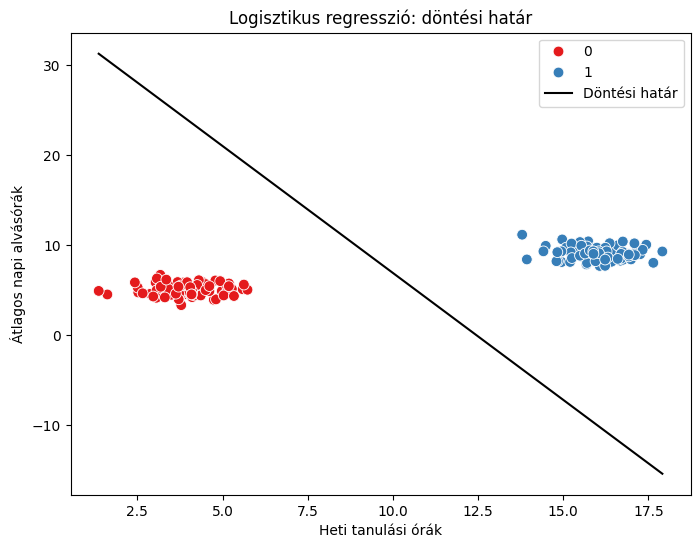

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Csak a rosszul (0) és jól (2) teljesítők
df_binary = df[df['exam_result'].isin([0,2])].copy()

# Bináris címke létrehozása: 0 = rosszul, 1 = jól
df_binary['pass_binary'] = (df_binary['exam_result'] == 2).astype(int)

# Független változók: study_hours és sleep_hours
X = df_binary[['study_hours', 'sleep_hours']]
y = df_binary['pass_binary']

# Logisztikus regresszió tanítása
reg = LogisticRegression()
reg.fit(X, y)

# A döntési határ kiszámítása: theta0 + theta1*x1 + theta2*x2 = 0
theta0 = reg.intercept_[0]
theta1 = reg.coef_[0,0]
theta2 = reg.coef_[0,1]

# x2 (sleep_hours) a döntési határ a study_hours függvényében
x2_boundary = -(theta0 + theta1*X['study_hours']) / theta2

# Scatter plot a valós címkékkel, line plot a döntési határral
plt.figure(figsize=(8,6))
sns.scatterplot(x=X['study_hours'], y=X['sleep_hours'], hue=y, palette='Set1', s=60)
sns.lineplot(x=X['study_hours'], y=x2_boundary, color='black', label='Döntési határ')
plt.xlabel("Heti tanulási órák")
plt.ylabel("Átlagos napi alvásórák")
plt.title("Logisztikus regresszió: döntési határ")
plt.legend()
plt.show()